In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

RAW_PROCESSED_PATH = "../data/processed/"
df_monthly_clean = pd.read_csv(RAW_PROCESSED_PATH + "sales_monthly_clean.csv")

df_monthly_clean['datum'] = pd.to_datetime(df_monthly_clean['datum'])
df_monthly_clean.set_index('datum', inplace = True)

drug_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
df_monthly_clean['total_sales'] = df_monthly_clean[drug_cols].sum(axis=1)

print(f"Month sales : {df_monthly_clean['total_sales']}")

Month sales : datum
2014-01-31    1821.110
2014-02-28    1974.470
2014-03-31    1606.720
2014-04-30    1429.675
2014-05-31    1506.303
                ...   
2019-06-30    1482.407
2019-07-31    1517.941
2019-08-31    1377.779
2019-09-30    1864.387
2019-10-31     538.600
Name: total_sales, Length: 70, dtype: float64


In [28]:
def run_adf_test(series, name):

    result = adfuller(series)

    print("ADF Statistic: ", result[0])
    print("P-Value: ", result[1])

    if (result[1] < 0.05):
        print("Stationary")
    else:
        print("Non-Stationary")

run_adf_test(df_monthly_clean['total_sales'], "Total Sales")

ADF Statistic:  -3.378636528809362
P-Value:  0.011709070853159559
Stationary


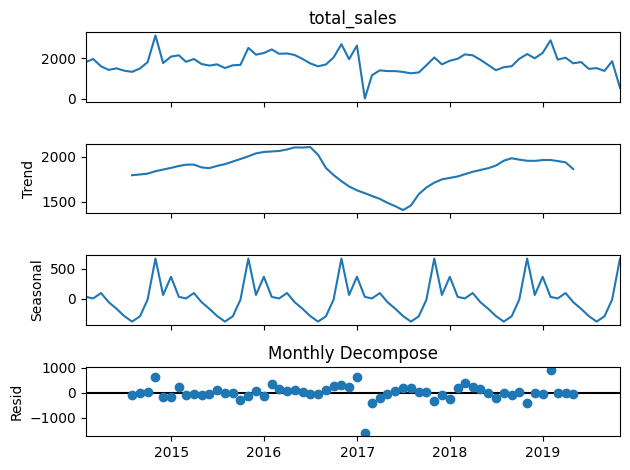

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_decompose = seasonal_decompose(df_monthly_clean['total_sales'], model = 'additive', period = 12)

monthly_decompose.plot()
plt.title('Monthly Decompose')
plt.tight_layout()

Text(0.5, 1.0, 'PACF')

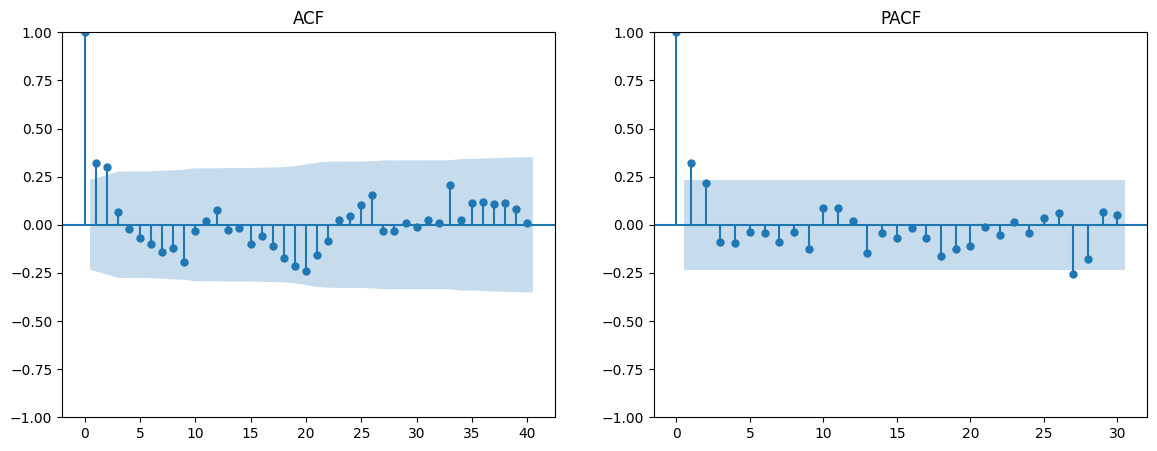

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))
plot_acf(df_monthly_clean['total_sales'], lags=40, ax=ax1)
plot_pacf(df_monthly_clean['total_sales'], lags=30, ax=ax2)

ax1.set_title('ACF')
ax2.set_title('PACF')